<a href="https://colab.research.google.com/github/Chinolis18/InstrumentacionIB_2025/blob/main/CNN_demo_estudiantes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧠 Redes Neuronales Convolucionales (CNN) — Demo interactiva

**Visión por Computadora · Aprendizaje Profundo**

De los píxeles a la predicción, paso a paso. Este notebook acompaña la presentación
y sigue el mismo recorrido:

1. La imagen como números
2. La convolución a mano (deslizar · multiplicar · sumar)
3. ReLU — la no linealidad
4. Pooling — resumir y comprimir
5. Construir la CNN completa (la de la diapositiva del código)
6. Entrenar sobre MNIST
7. Ver qué aprendió: filtros y mapas de características
8. Clasificar un dígito y ver las probabilidades
9. Ejercicios para experimentar

> 💡 **Antes de empezar:** activa la GPU en Colab → menú **Entorno de ejecución → Cambiar tipo de entorno de ejecución → GPU**. No es obligatorio, pero acelera el entrenamiento.


## ⚙️ Preparación

Importamos las librerías. En Colab ya vienen instaladas; no hace falta instalar nada.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, datasets

np.random.seed(0)
tf.random.set_seed(0)

print("TensorFlow:", tf.__version__)
print("GPU disponible:", "Sí ✅" if tf.config.list_physical_devices('GPU') else "No (usará CPU, igual funciona) ⚠️")

TensorFlow: 2.20.0
GPU disponible: Sí ✅


## 1️⃣ La imagen como números

Para la computadora, una imagen es **una matriz de números**. Cada celda guarda la
intensidad de un píxel: `0 = negro`, `255 = blanco` (en escala de grises).

Cargamos MNIST: 70 000 dígitos escritos a mano de 28×28 píxeles.

In [ ]:
(x_train, y_train), (x_test, y_test) = datasets.mnist.load_data()
print("Imágenes de entrenamiento:", x_train.shape)   # (60000, 28, 28)
print("Imágenes de prueba:       ", x_test.shape)     # (10000, 28, 28)
print("Una imagen es una matriz de", x_train[0].shape, "valores entre 0 y 255")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Imágenes de entrenamiento: (60000, 28, 28)
Imágenes de prueba:        (10000, 28, 28)
Una imagen es una matriz de (28, 28) valores entre 0 y 255


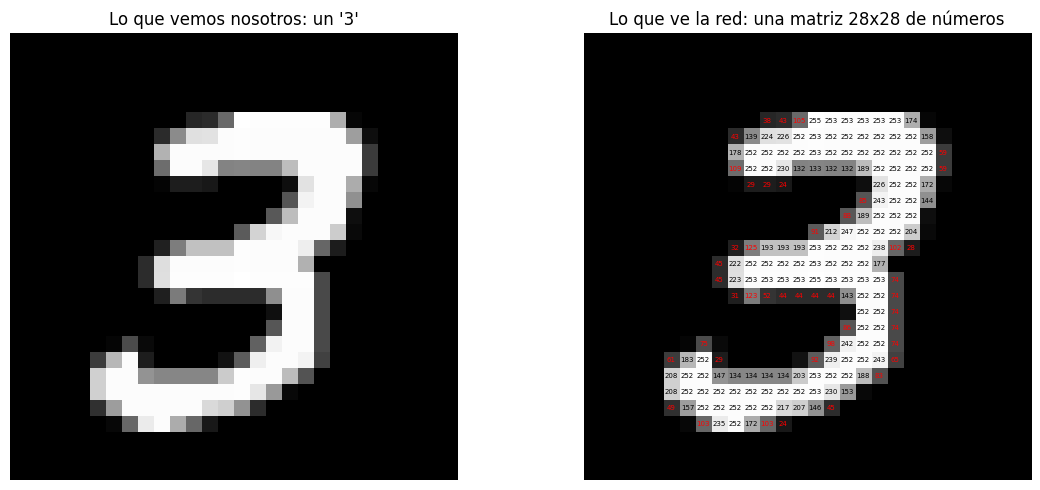

In [ ]:
# Elegimos un dígito y lo mostramos como imagen Y como números
idx = 7                      # 👉 cambia este número para ver otros dígitos
img = x_train[idx]
etiqueta = y_train[idx]

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].imshow(img, cmap='gray')
ax[0].set_title(f"Lo que vemos nosotros: un '{etiqueta}'")
ax[0].axis('off')

# La red NUNCA ve un dígito: solo ve esta cuadrícula de números
ax[1].imshow(img, cmap='gray')
ax[1].set_title("Lo que ve la red: una matriz 28x28 de números")
for i in range(28):
    for j in range(28):
        v = img[i, j]
        if v > 20:  # solo anotamos píxeles con algo de brillo, para no saturar
            ax[1].text(j, i, str(v), ha='center', va='center',
                       fontsize=5, color='red' if v < 128 else 'black')
ax[1].axis('off')
plt.tight_layout(); plt.show()

## 2️⃣ La convolución a mano

La convolución consiste en **deslizar un filtro pequeño** sobre la imagen, y en cada
posición: *multiplicar* cada píxel por el valor del filtro encima y *sumar* todo.

$$\text{salida} = \sum (\text{entrada} \cdot \text{filtro})$$

El resultado es un **mapa de características**: dónde y cuánto aparece el patrón que el filtro busca.

Aquí lo implementamos nosotros mismos (sin librerías mágicas) para que se vea el mecanismo.

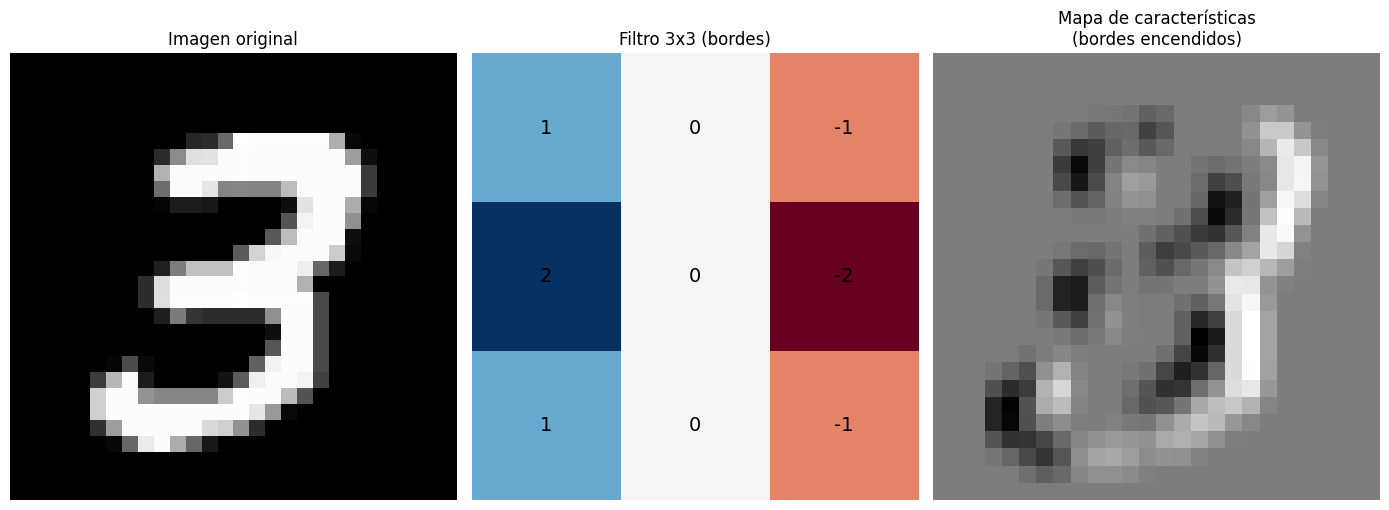

In [ ]:
def convolucion_2d(imagen, filtro):
    """Convolución (correlación) 2D 'a mano', sin padding, stride=1."""
    H, W = imagen.shape
    kH, kW = filtro.shape
    salida = np.zeros((H - kH + 1, W - kW + 1))
    for i in range(salida.shape[0]):
        for j in range(salida.shape[1]):
            ventana = imagen[i:i+kH, j:j+kW]      # la ventana que mira el filtro
            salida[i, j] = np.sum(ventana * filtro)  # multiplicar y sumar
    return salida

# Filtro detector de bordes verticales (Sobel) — el mismo de la presentación
filtro_bordes = np.array([[ 1, 0, -1],
                          [ 2, 0, -2],
                          [ 1, 0, -1]], dtype=float)

img = x_train[idx].astype(float)
mapa = convolucion_2d(img, filtro_bordes)

fig, ax = plt.subplots(1, 3, figsize=(14, 5))
ax[0].imshow(img, cmap='gray');  ax[0].set_title("Imagen original");   ax[0].axis('off')
ax[1].imshow(filtro_bordes, cmap='RdBu'); ax[1].set_title("Filtro 3x3 (bordes)")
for i in range(3):
    for j in range(3):
        ax[1].text(j, i, int(filtro_bordes[i, j]), ha='center', va='center', fontsize=14)
ax[1].axis('off')
ax[2].imshow(mapa, cmap='gray'); ax[2].set_title("Mapa de características\n(bordes encendidos)"); ax[2].axis('off')
plt.tight_layout(); plt.show()

**Prueba tú:** descomenta un filtro distinto y vuelve a ejecutar la celda de arriba
cambiando `filtro_bordes`. Lo poderoso de una CNN es que **no le damos estos números**:
la red **aprende los valores del filtro sola** durante el entrenamiento.

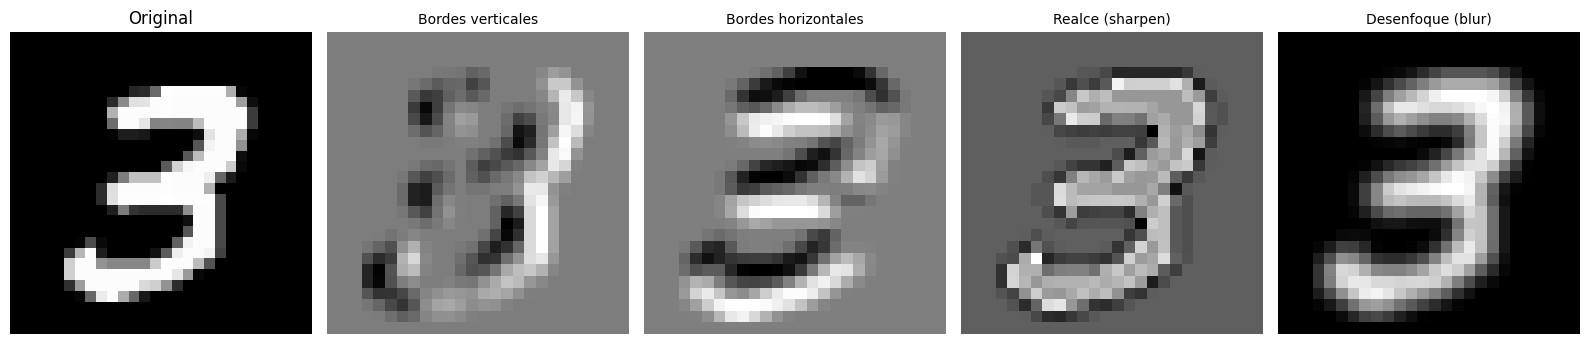

In [ ]:
# Galería de filtros clásicos para experimentar 🔬
filtros = {
    "Bordes verticales":   np.array([[1,0,-1],[2,0,-2],[1,0,-1]], float),
    "Bordes horizontales": np.array([[1,2,1],[0,0,0],[-1,-2,-1]], float),
    "Realce (sharpen)":    np.array([[0,-1,0],[-1,5,-1],[0,-1,0]], float),
    "Desenfoque (blur)":   np.ones((3,3))/9.0,
}

fig, ax = plt.subplots(1, len(filtros)+1, figsize=(16, 4))
ax[0].imshow(img, cmap='gray'); ax[0].set_title("Original"); ax[0].axis('off')
for k, (nombre, f) in enumerate(filtros.items(), start=1):
    ax[k].imshow(convolucion_2d(img, f), cmap='gray')
    ax[k].set_title(nombre, fontsize=10); ax[k].axis('off')
plt.tight_layout(); plt.show()

## 3️⃣ ReLU — introducir la no linealidad

Tras cada convolución aplicamos **ReLU**: si un valor es negativo lo vuelve `0`;
si es positivo lo deja igual.

$$f(x) = \max(0,\, x)$$

Sin esta no linealidad, apilar capas sería inútil: todo seguiría siendo una
combinación lineal.

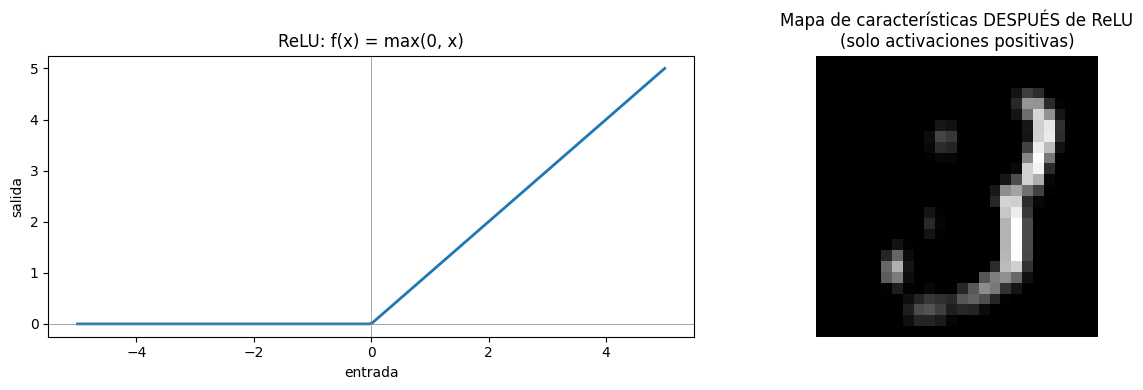

In [ ]:
def relu(x):
    return np.maximum(0, x)

x = np.linspace(-5, 5, 200)
fig, ax = plt.subplots(1, 2, figsize=(13, 4))

ax[0].plot(x, relu(x), lw=2)
ax[0].axhline(0, color='gray', lw=.5); ax[0].axvline(0, color='gray', lw=.5)
ax[0].set_title("ReLU: f(x) = max(0, x)"); ax[0].set_xlabel("entrada"); ax[0].set_ylabel("salida")

# ReLU sobre el mapa de características: lo negativo se apaga
ax[1].imshow(relu(mapa), cmap='gray')
ax[1].set_title("Mapa de características DESPUÉS de ReLU\n(solo activaciones positivas)")
ax[1].axis('off')
plt.tight_layout(); plt.show()

## 4️⃣ Pooling — resumir y comprimir

Dividimos el mapa en bloques y nos quedamos con **un valor por bloque**.
El más común es **max-pooling**: el máximo de cada bloque (conserva la activación
más fuerte). Reduce el cómputo, controla el sobreajuste y da tolerancia a pequeños
desplazamientos del objeto.

Mapa 4x4:
 [[1. 3. 2. 4.]
 [5. 6. 1. 2.]
 [7. 2. 3. 0.]
 [1. 2. 4. 8.]]

Max-pooling 2x2 (stride 2):
 [[6. 4.]
 [7. 8.]]


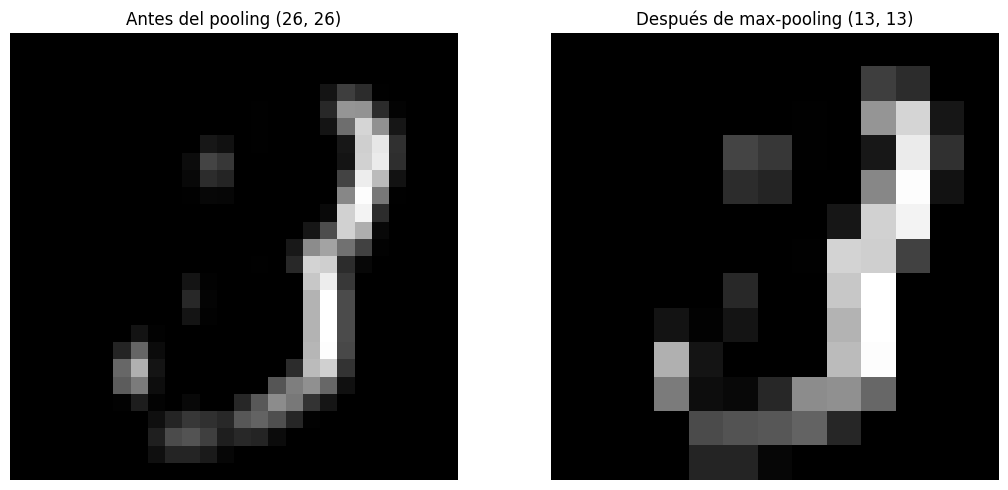

In [ ]:
def max_pooling(mapa, tam=2, stride=2):
    H, W = mapa.shape
    oH = (H - tam) // stride + 1
    oW = (W - tam) // stride + 1
    salida = np.zeros((oH, oW))
    for i in range(oH):
        for j in range(oW):
            bloque = mapa[i*stride:i*stride+tam, j*stride:j*stride+tam]
            salida[i, j] = np.max(bloque)
    return salida

# Ejemplo idéntico al de la diapositiva
ejemplo = np.array([[1,3,2,4],
                    [5,6,1,2],
                    [7,2,3,0],
                    [1,2,4,8]], float)
print("Mapa 4x4:\n", ejemplo)
print("\nMax-pooling 2x2 (stride 2):\n", max_pooling(ejemplo))

# Y sobre nuestro mapa real
activado = relu(mapa)
fig, ax = plt.subplots(1, 2, figsize=(11, 5))
ax[0].imshow(activado, cmap='gray'); ax[0].set_title(f"Antes del pooling {activado.shape}"); ax[0].axis('off')
reducido = max_pooling(activado)
ax[1].imshow(reducido, cmap='gray'); ax[1].set_title(f"Después de max-pooling {reducido.shape}"); ax[1].axis('off')
plt.tight_layout(); plt.show()

## 5️⃣ Construir la CNN completa

Ahora dejamos que Keras haga todo lo anterior por nosotros. Esta es **exactamente la
arquitectura de la presentación**:

`ENTRADA → CONV+ReLU → POOL → CONV+ReLU → POOL → FLATTEN → DENSE → SOFTMAX`

Primero preparamos los datos: normalizamos a `[0,1]` y añadimos el canal (la red espera
un volumen `alto × ancho × canales`).

In [ ]:
# Normalizar y dar forma (28, 28, 1)
x_train_n = (x_train.astype('float32') / 255.0)[..., None]
x_test_n  = (x_test.astype('float32')  / 255.0)[..., None]
print("Forma de entrada al modelo:", x_train_n.shape[1:])

Forma de entrada al modelo: (28, 28, 1)


In [ ]:
model = models.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, (3, 3), activation='relu'),   # 32 filtros 3x3 -> 32 mapas
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),   # 64 filtros 3x3
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),                               # aplanar el volumen
    layers.Dense(128, activation='relu'),
    layers.Dense(10,  activation='softmax'),        # 10 clases -> probabilidades
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

Fíjate en la columna **Output Shape** del resumen: ves cómo el volumen cambia de tamaño
exactamente como en la diapositiva de la arquitectura `28×28×1 → 26×26×32 → 13×13×32 →
11×11×64 → 5×5×64 → 1600 → 128 → 10`.

## 6️⃣ Entrenar sobre MNIST

Entrenamos solo unas pocas épocas: MNIST es fácil y la red llega a ~99% rápido.
Reservamos un 10% para validación.

In [ ]:
historia = model.fit(
    x_train_n, y_train,
    epochs=5,
    batch_size=128,
    validation_split=0.1,
    verbose=1,
)

Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.9332 - loss: 0.2223 - val_accuracy: 0.9783 - val_loss: 0.0697
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9815 - loss: 0.0614 - val_accuracy: 0.9855 - val_loss: 0.0482
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9876 - loss: 0.0418 - val_accuracy: 0.9877 - val_loss: 0.0424
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9906 - loss: 0.0321 - val_accuracy: 0.9877 - val_loss: 0.0403
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9928 - loss: 0.0246 - val_accuracy: 0.9887 - val_loss: 0.0413


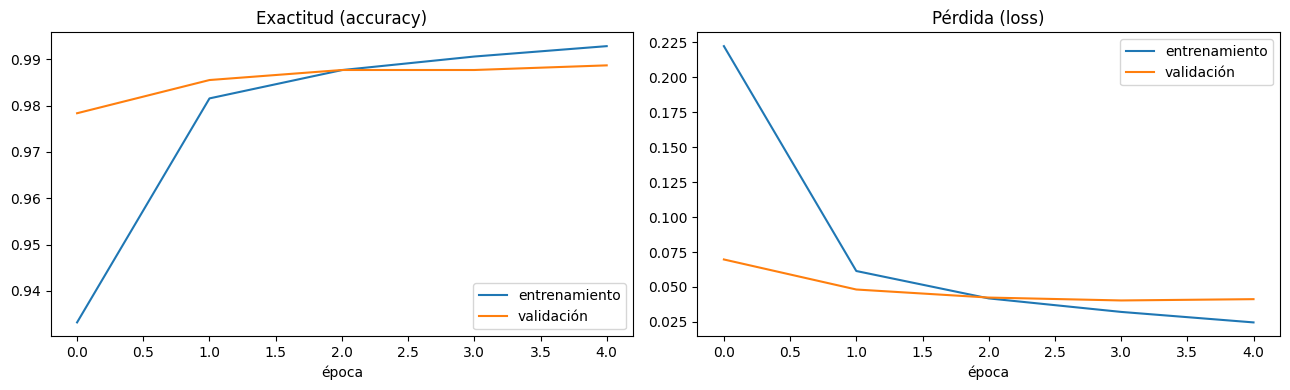


🎯 Exactitud en datos de prueba (nunca vistos): 98.96%


In [ ]:
# Curvas de aprendizaje
h = historia.history
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(h['accuracy'], label='entrenamiento')
ax[0].plot(h['val_accuracy'], label='validación')
ax[0].set_title('Exactitud (accuracy)'); ax[0].set_xlabel('época'); ax[0].legend()
ax[1].plot(h['loss'], label='entrenamiento')
ax[1].plot(h['val_loss'], label='validación')
ax[1].set_title('Pérdida (loss)'); ax[1].set_xlabel('época'); ax[1].legend()
plt.tight_layout(); plt.show()

test_loss, test_acc = model.evaluate(x_test_n, y_test, verbose=0)
print(f"\n🎯 Exactitud en datos de prueba (nunca vistos): {test_acc*100:.2f}%")

## 7️⃣ ¿Qué aprendió la red? Filtros y mapas de características

La CNN **aprendió los filtros sola**. Vamos a mirarlos, y también a ver los mapas de
características que produce sobre un dígito real (capas iniciales → bordes, capas
profundas → patrones más abstractos).

Forma de los filtros de la 1a capa: (3, 3, 1, 32)


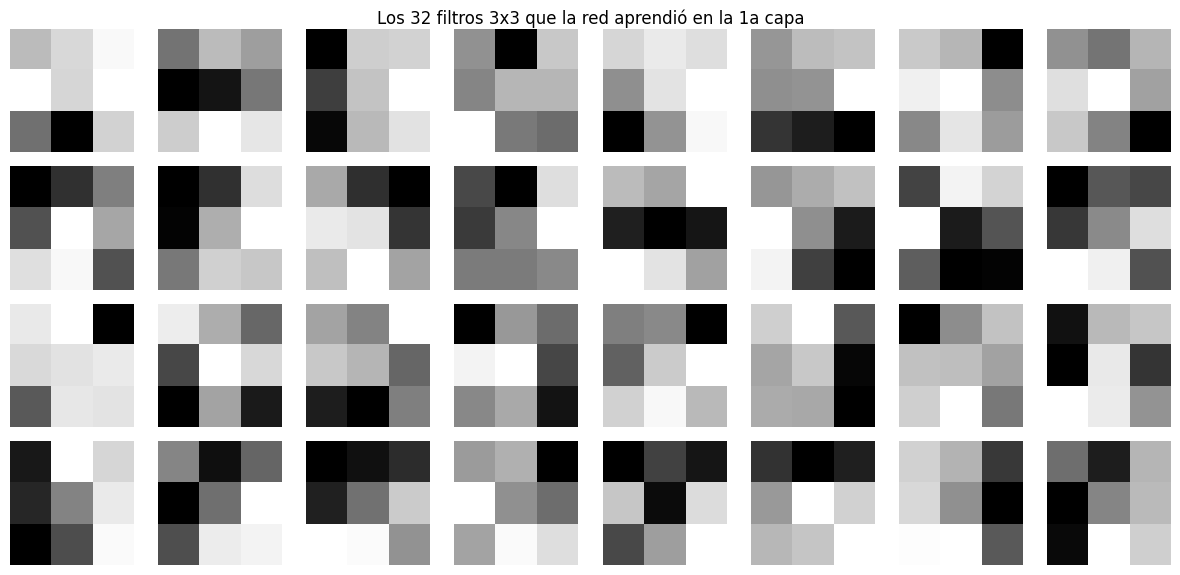

In [ ]:
# Los 32 filtros aprendidos de la primera capa convolucional
pesos = model.layers[0].get_weights()[0]   # forma (3, 3, 1, 32)
print("Forma de los filtros de la 1a capa:", pesos.shape)

fig, axes = plt.subplots(4, 8, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    ax.imshow(pesos[:, :, 0, i], cmap='gray')
    ax.axis('off')
fig.suptitle("Los 32 filtros 3x3 que la red aprendió en la 1a capa", y=0.95)
plt.tight_layout(); plt.show()

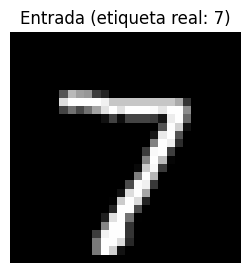

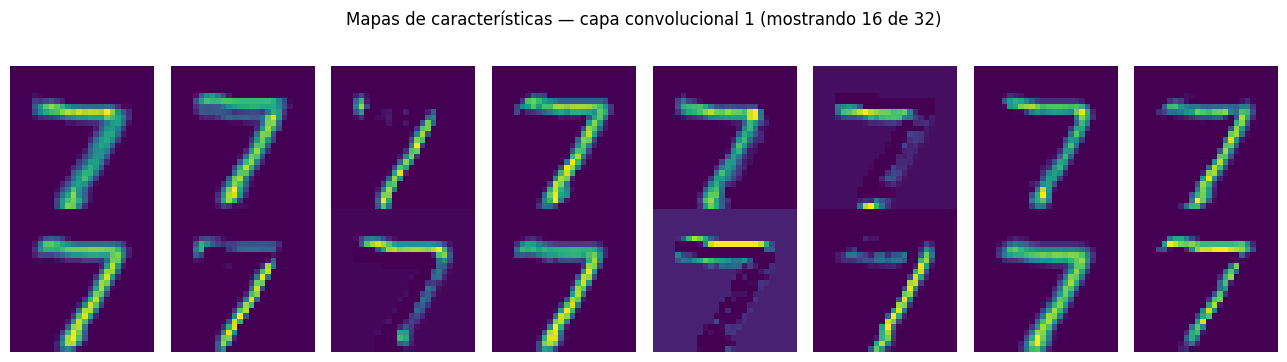

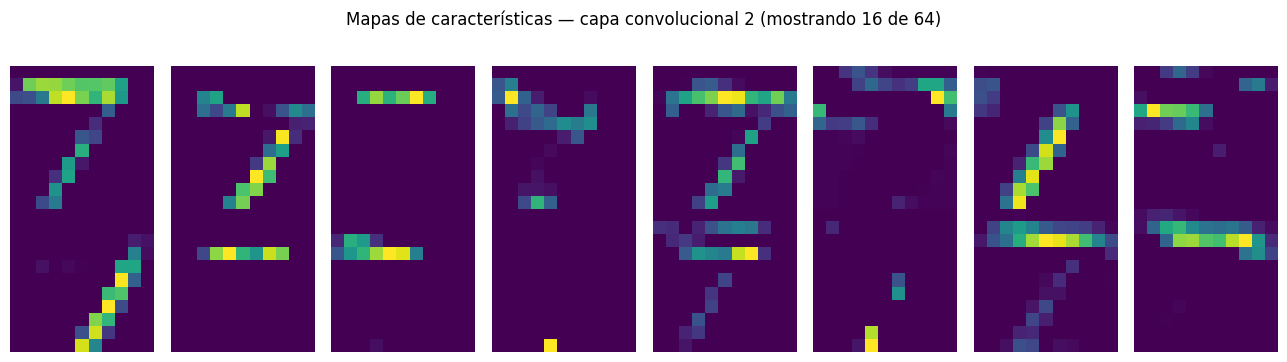

In [ ]:
# Mapas de características: la salida de cada capa convolucional para UN dígito
capas_conv = [l for l in model.layers if isinstance(l, layers.Conv2D)]
activacion_model = models.Model(inputs=model.inputs,
                                outputs=[l.output for l in capas_conv])

muestra = x_test_n[0:1]                 # 👉 cambia el índice para probar otro dígito
mapas = activacion_model.predict(muestra, verbose=0)

plt.figure(figsize=(3, 3))
plt.imshow(muestra[0, :, :, 0], cmap='gray')
plt.title(f"Entrada (etiqueta real: {y_test[0]})"); plt.axis('off'); plt.show()

for capa_i, mapa_capa in enumerate(mapas):
    n = min(16, mapa_capa.shape[-1])
    fig, axes = plt.subplots(2, 8, figsize=(13, 3.5))
    for f, ax in enumerate(axes.flat):
        if f < n:
            ax.imshow(mapa_capa[0, :, :, f], cmap='viridis')
        ax.axis('off')
    fig.suptitle(f"Mapas de características — capa convolucional {capa_i+1} "
                 f"(mostrando {n} de {mapa_capa.shape[-1]})", y=1.02)
    plt.tight_layout(); plt.show()

## 8️⃣ Clasificar un dígito y ver las probabilidades

Igual que en la diapositiva: la red entrega un vector de probabilidades (softmax) y su
predicción es la clase con el valor más alto.

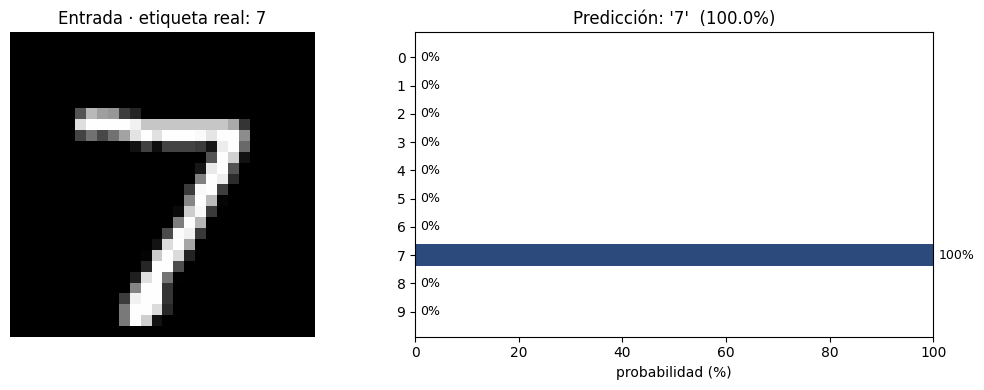

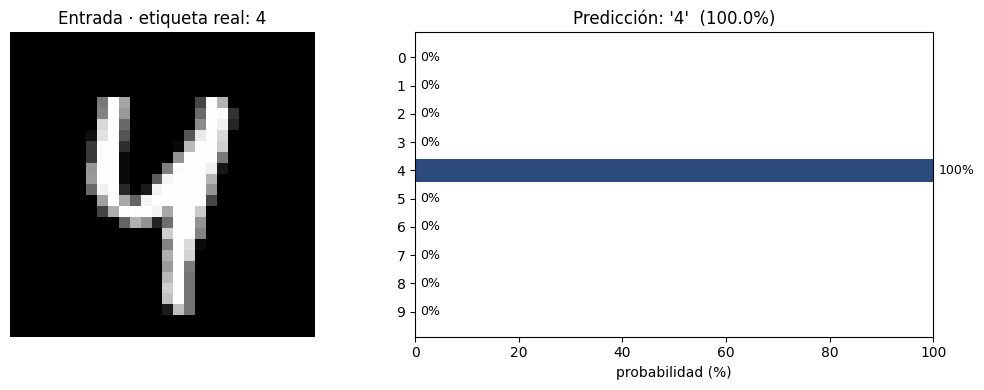

In [ ]:
def predecir_y_mostrar(i):
    muestra = x_test_n[i:i+1]
    probs = model.predict(muestra, verbose=0)[0]
    pred = int(np.argmax(probs))

    fig, ax = plt.subplots(1, 2, figsize=(11, 4))
    ax[0].imshow(x_test[i], cmap='gray')
    ax[0].set_title(f"Entrada · etiqueta real: {y_test[i]}"); ax[0].axis('off')

    colores = ['#2d4a7c' if k == pred else '#dcd8cf' for k in range(10)]
    ax[1].barh(range(10), probs*100, color=colores)
    ax[1].set_yticks(range(10)); ax[1].invert_yaxis()
    ax[1].set_xlim(0, 100); ax[1].set_xlabel("probabilidad (%)")
    ax[1].set_title(f"Predicción: '{pred}'  ({probs[pred]*100:.1f}%)")
    for k, p in enumerate(probs):
        ax[1].text(p*100 + 1, k, f"{p*100:.0f}%", va='center', fontsize=9)
    plt.tight_layout(); plt.show()

predecir_y_mostrar(0)     # 👉 cambia el índice para clasificar otros dígitos
predecir_y_mostrar(42)

Errores: 104 de 10000 (1.04% de error)


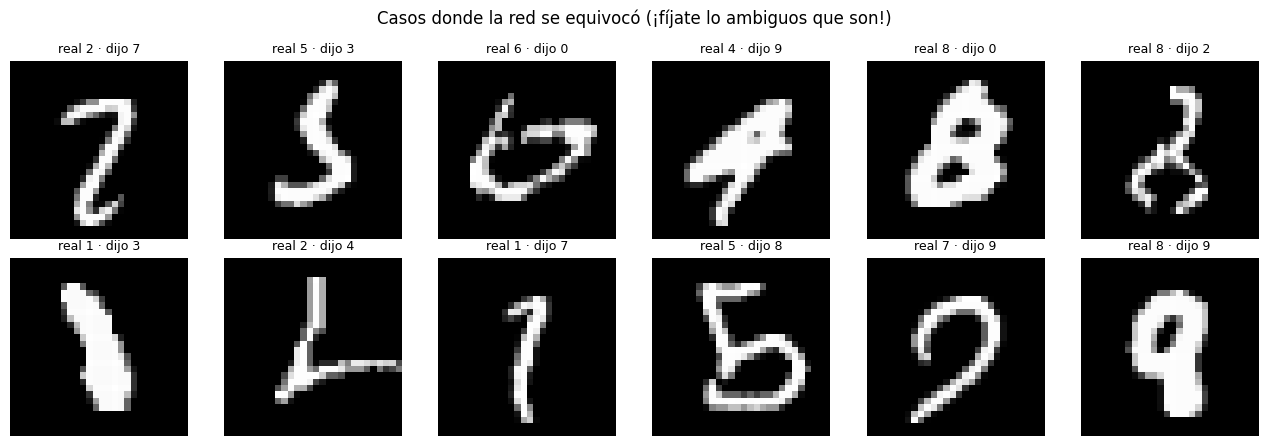

In [ ]:
# ¿Dónde se equivoca la red? Veamos algunos errores (suelen ser dígitos ambiguos)
preds = np.argmax(model.predict(x_test_n, verbose=0), axis=1)
errores = np.where(preds != y_test)[0]
print(f"Errores: {len(errores)} de {len(y_test)} "
      f"({100*len(errores)/len(y_test):.2f}% de error)")

fig, axes = plt.subplots(2, 6, figsize=(13, 4.5))
for ax, e in zip(axes.flat, errores[:12]):
    ax.imshow(x_test[e], cmap='gray')
    ax.set_title(f"real {y_test[e]} · dijo {preds[e]}", fontsize=9)
    ax.axis('off')
fig.suptitle("Casos donde la red se equivocó (¡fíjate lo ambiguos que son!)")
plt.tight_layout(); plt.show()

## 9️⃣ Ejercicios para experimentar 🧪

Modifica el código y observa qué pasa. Sugerencias:

1. **Más/menos filtros.** Cambia `Conv2D(32, ...)` por `16` o `64`. ¿Mejora la exactitud?
   ¿Cuántos parámetros tiene el modelo (mira `model.summary()`)?
2. **Quita el pooling.** Elimina las capas `MaxPooling2D`. ¿Qué pasa con el tamaño del
   `Flatten` y con el número de parámetros?
3. **Quita la ReLU** (pon `activation=None` en las `Conv2D`). ¿Cae mucho la exactitud?
   Esto demuestra para qué sirve la no linealidad.
4. **Filtro propio.** En la sección 2, escribe tu propia matriz 3×3 y observa qué detecta.
5. **Más épocas / menos datos.** Entrena con `epochs=10` o con solo `x_train_n[:5000]`.
   ¿Aparece sobreajuste (la validación empeora mientras el entrenamiento mejora)?
6. **Dibuja tu propio dígito.** Sube una imagen 28×28 en blanco y negro y pásala por la red.

---

### 🔗 Demo visual complementaria

Para ver una CNN activarse capa por capa en tiempo real mientras dibujas un dígito:
**adamharley.com/nn_vis/cnn/2d.html**

> *De los píxeles a la predicción: ahora ya sabes cómo una CNN aprende a ver.*


In [ ]:
# 📥 (Opcional) Pasar TU PROPIA imagen de un dígito por la red.
# Sube un archivo (png/jpg) con un dígito oscuro sobre fondo claro, o al revés.
# Descomenta para usarlo en Colab:

# from google.colab import files
# from PIL import Image, ImageOps
# subido = files.upload()
# nombre = list(subido.keys())[0]
# im = Image.open(nombre).convert('L').resize((28, 28))
# im = ImageOps.invert(im)                       # MNIST = dígito claro sobre fondo oscuro
# arr = (np.array(im).astype('float32') / 255.0)[None, ..., None]
# probs = model.predict(arr, verbose=0)[0]
# plt.imshow(arr[0, :, :, 0], cmap='gray'); plt.axis('off')
# plt.title(f"Predicción: {np.argmax(probs)} ({probs.max()*100:.0f}%)"); plt.show()
print("Listo. ¡Experimenta y rompe cosas: así se aprende! 🚀")

Listo. ¡Experimenta y rompe cosas: así se aprende! 🚀
